In [7]:
# importing the required libraries for customer segmentation problem
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [8]:
# Loading the dataset
df = pd.read_csv(r'D:\Three-capstone-projects\segmentation\dataset\Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [11]:
df.drop(columns=['CustomerID'], inplace=True)

In [12]:
df.shape

(200, 4)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Gender                  200 non-null    str  
 1   Age                     200 non-null    int64
 2   Annual Income (k$)      200 non-null    int64
 3   Spending Score (1-100)  200 non-null    int64
dtypes: int64(3), str(1)
memory usage: 7.4 KB


In [14]:
df.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


In [15]:
df.isnull().sum()

Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [16]:
# check for duplicated values
df.duplicated().sum()

np.int64(0)

In [17]:
# Getting numerical columns from dataset
numerical_columns = df.select_dtypes(include=['int64','float64']).columns

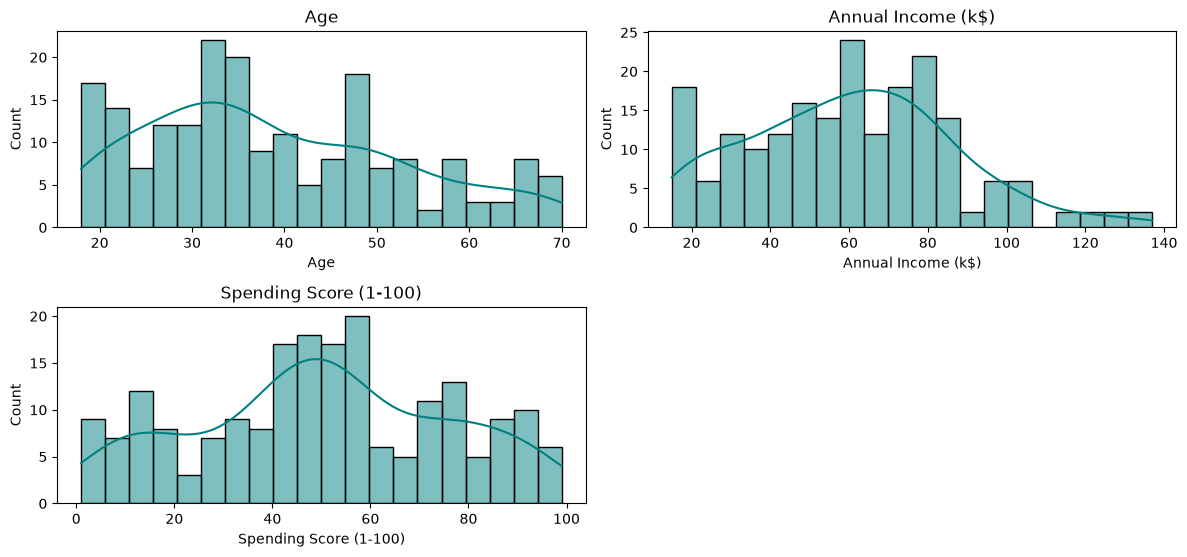

In [18]:
# Analyzing the numerical features by histogram and boxplot for any possible outlier
plt.figure(figsize=(12,8))
for i, col in enumerate(numerical_columns):
    plt.subplot(3,2,i+1) #rows, columns and index
    sns.histplot(data=df, x=col, bins=20, kde=True, color="teal")
    plt.title(f"{col}")
plt.tight_layout()
plt.show()

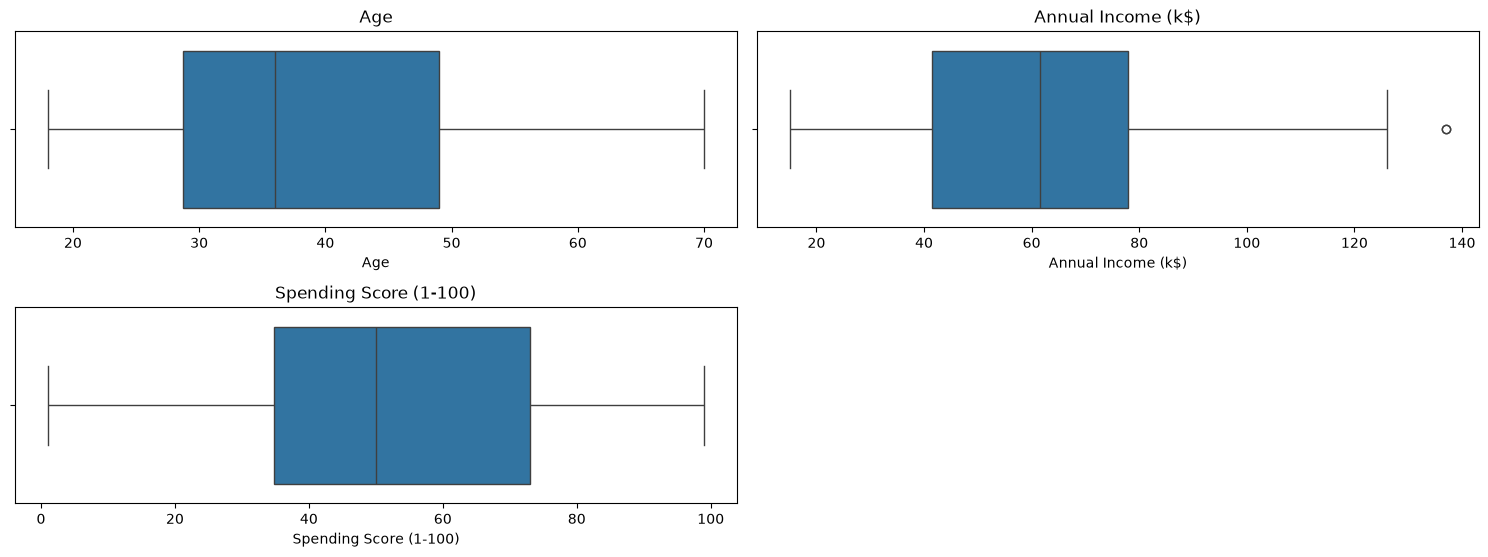

In [19]:
# Analyzing the numerical features by using box plot
plt.figure(figsize=(15,8))
for i ,col in enumerate(numerical_columns):
    plt.subplot(3,2,i+1) # i+1 to start index from 1
    sns.boxplot(data=df,x=col)
    plt.title(col)
plt.tight_layout()
plt.show()

No noteable outlier found in the dataset

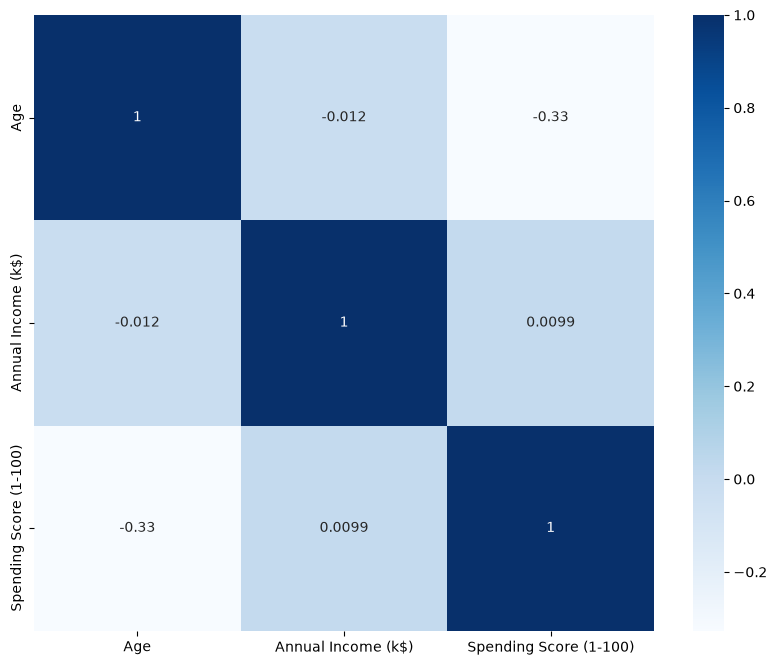

In [20]:
# co-relation matrix of the numercial features
plt.figure(figsize=(10,8))
sns.heatmap(df[numerical_columns].corr(),annot=True,cmap='Blues')
plt.show()

By observing the correlation matrix we can conclude that it is strictly segmenation problem as there is almost zero corelation among the features it's mean that are distinct to eah other. So we can solve it by clustirng technique such as k-means

In [21]:
# Seprating the features by making copy no target variable as clustring is unsupervised
X = df.copy()

In [22]:
X.isnull().sum()

Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [23]:
# getting the categorical features of X
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
# categorical_features = categorical_features[:1]
categorical_features

['Gender']

In [24]:
# getting the numerical features of X
# X["Annual Income ($)"] = np.log1p(X["Annual Income ($)"])
numerical_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
numerical_features.remove('Age') # Multiple training itration and co-relation indicated that removing age make score better
numerical_features

['Annual Income (k$)', 'Spending Score (1-100)']

In [25]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,MinMaxScaler
# defining preprocessor pipline to use columntransformer production standard
preprocessor = ColumnTransformer(
    transformers=[
        # categorical variables are effecting the effeicient clustring, not consider it
        # (
        #     "cat",
        #     OneHotEncoder(handle_unknown="ignore", sparse_output=False), # encoding using onhotencoder for categorical variables of training data
        #     categorical_features
        # ),
        (
            "num",
            StandardScaler(), #scaling the numerical features as we larger range of numbers and also required for k-means
            numerical_features
        )
    ]
)

In [26]:
from sklearn.decomposition import PCA
# 1. Preprocess the data
X_processed = preprocessor.fit_transform(X)
# 2. Reduce dimensions to filter out noise from one-hot encoding
# pca = PCA(n_components=2, random_state=42)
# X_pca = pca.fit_transform(X_processed)

In [27]:
# Transform the data and then defining Elbow method to find appropraite number of clusters

from sklearn.cluster import KMeans
inertia = []
for i in range(2,11):
    model = KMeans(n_clusters=i,init='k-means++',random_state=42,n_init=10)
    model.fit(X_processed)
    inertia.append(model.inertia_)
    print(f"Inertia for {i} clusters: {model.inertia_}")
    print("-"*50)



Inertia for 2 clusters: 269.69101219276394
--------------------------------------------------
Inertia for 3 clusters: 157.70400815035947
--------------------------------------------------
Inertia for 4 clusters: 108.92131661364357
--------------------------------------------------
Inertia for 5 clusters: 65.56840815571681
--------------------------------------------------
Inertia for 6 clusters: 55.057348270386
--------------------------------------------------
Inertia for 7 clusters: 44.86475569922557
--------------------------------------------------
Inertia for 8 clusters: 37.228187677585886
--------------------------------------------------
Inertia for 9 clusters: 32.392267630331176
--------------------------------------------------
Inertia for 10 clusters: 29.981897788243693
--------------------------------------------------


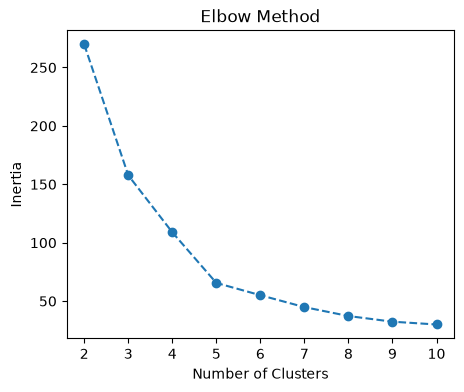

In [28]:
# plotting the inertia 10 numbers using line plot for best fitted elbow
plt.figure(figsize=(5,4))
plt.plot(range(2,11),inertia,marker='o',linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [29]:
# Verify the Elbow Method using silhouette_score
from sklearn.metrics import silhouette_score
for k in [2, 3, 4, 5, 6]: # check for the best possible number of clusters
    test_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    test_clusters = test_model.fit_predict(X_processed)
    print(f"K={k} | Silhouette Score: {silhouette_score(X_processed, test_clusters):.4f}")

K=2 | Silhouette Score: 0.3213
K=3 | Silhouette Score: 0.4666
K=4 | Silhouette Score: 0.4939
K=5 | Silhouette Score: 0.5547
K=6 | Silhouette Score: 0.5399


In [30]:
# Select n_cluster = 5 as it is giving best curve in elbow method and same is reflected in silhouette_score
model = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = model.fit_predict(X_processed)
score = silhouette_score(X_processed, clusters)
print(score)

0.5546571631111091


In [31]:
# Final pipline and model training
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        KMeans(
            n_clusters=5,
            random_state=42,
            n_init=10
        )
    )

])

In [32]:
# Final step for the model training
pipeline.fit(X)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['Gender','Age','Annual Income (k$)','Spending Score (1-100)']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the 

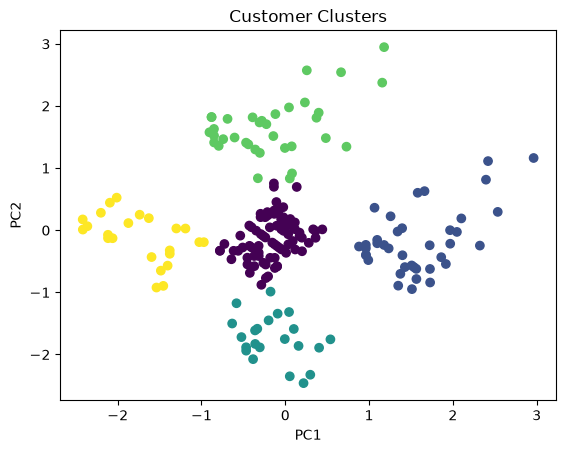

In [33]:
# PCA to visulaize the clusters
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap="viridis"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Clusters")
plt.show()

In [34]:
clusters = pipeline.predict(X)

df["Cluster"] = clusters

In [35]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,Male,19,15,39,4
1,Male,21,15,81,2
2,Female,20,16,6,4
3,Female,23,16,77,2
4,Female,31,17,40,4


In [36]:
df.groupby("Cluster").mean(numeric_only=True)

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


In [37]:
df["Cluster"].value_counts()

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64

In [38]:
# identify charactretics of each cluster
df.groupby("Cluster").describe().T


Cluster                               0           1          2           3  \
Age                    count  81.000000   39.000000  22.000000   35.000000   
                       mean   42.716049   32.692308  25.272727   41.114286   
                       std    16.447822    3.728650   5.257030   11.341676   
                       min    18.000000   27.000000  18.000000   19.000000   
                       25%    27.000000   30.000000  21.250000   34.000000   
                       50%    46.000000   32.000000  23.500000   42.000000   
                       75%    54.000000   35.500000  29.750000   47.500000   
                       max    70.000000   40.000000  35.000000   59.000000   
Annual Income (k$)     count  81.000000   39.000000  22.000000   35.000000   
                       mean   55.296296   86.538462  25.727273   88.200000   
                       std     8.988109   16.312485   7.566731   16.399067   
                       min    39.000000   69.000000  15.000000   70.000000   
                       25%    48.000000   75.500000  19.250000   77.500000   
                       50%    54.000000   79.000000  24.500000   85.000000   
                       75%    62.000000   95.000000  32.250000   97.500000   
                       max    76.000000  137.000000  39.000000  137.000000   
Spending Score (1-100) count  81.000000   39.000000  22.000000   35.000000   
                       mean   49.518519   82.128205  79.363636   17.114286   
                       std     6.530909    9.364489  10.504174    9.952154   
                       min    34.000000   63.000000  61.000000    1.000000   
                       25%    44.000000   74.500000  73.000000   10.000000   
                       50%    50.000000   83.000000  77.000000   16.000000   
                       75%    55.000000   90.000000  85.750000   23.500000   
                       max    61.000000   97.000000  99.000000   39.000000   

Cluster                               4  
Age                    count  23.000000  
                       mean   45.217391  
                       std    13.228607  
                       min    19.000000  
                       25%    35.500000  
                       50%    46.000000  
                       75%    53.500000  
                       max    67.000000  
Annual Income (k$)     count  23.000000  
                       mean   26.304348  
                       std     7.893811  
                       min    15.000000  
                       25%    19.500000  
                       50%    25.000000  
                       75%    33.000000  
                       max    39.000000  
Spending Score (1-100) count  23.000000  
                       mean   20.913043  
                       std    13.017167  
                       min     3.000000  
                       25%     9.500000  
                       50%    17.000000  
                       75%    33.500000  
                       max    40.000000

In [39]:
# cluster summary table
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)
cluster_summary["Count"] = df["Cluster"].value_counts()
cluster_summary.index.name = "Cluster"
cluster_summary.reset_index(inplace=True)
cluster_summary

,Cluster,Age,Annual Income (k$),Spending Score (1-100),Count
0,0,42.716049,55.296296,49.518519,81
1,1,32.692308,86.538462,82.128205,39
2,2,25.272727,25.727273,79.363636,22
3,3,41.114286,88.200000,17.114286,35
4,4,45.217391,26.304348,20.913043,23


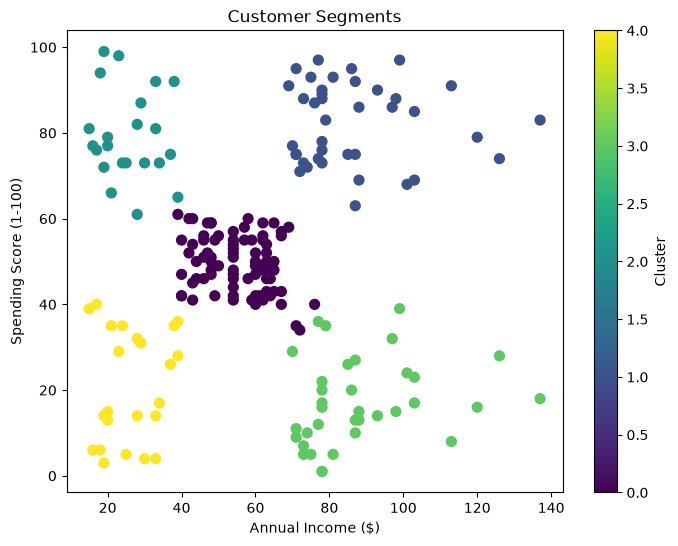

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis",
    s=50
)

plt.xlabel("Annual Income ($)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments")
plt.colorbar(label="Cluster")

plt.show()

In [43]:
import joblib
joblib.dump(pipeline, "customer_segmentation.joblib")

['customer_segmentation.joblib']